In [6]:
import sys, os
import pandas as pd
sys.path.append(os.path.join(os.getcwd(), '..'))
import utils.classifiers as classifiers
import utils.normalizer as normalizer
import data_getter

dg = data_getter.get_data_getter({
    "type": "csv",
    "data_dir": os.path.join(os.environ['HOME'], 'git/pyAnomalyDetector/tests/testdata/csv/20250407_0830'),
})

endep = int(1743981194) # 2025-04-07 08:59:54
t_endep = int(endep - 3600 * 6 )
startep = t_endep
t_startep = int(t_endep - 3600 * 24 * 7)
itemIds = [230624,230598,256815,230599,230593,268049,246909,360205,240289,230622,230618,
           230594,230592,256785,230626,258310,240291,240285,281715,230597,256679,260016,
           82295,141287,240282,360203,230600,230595,230619,257091,230565,230596,256788,
           230625,256681,256802,240286,256789,256784,257092,230621,179109,230620]

t_data = dg.get_trends_data(t_startep, t_endep, itemIds) # pd.DataFrame
h_data = dg.get_history_data(startep, endep, itemIds) # pd.DataFrame

chart_stats = normalizer.get_chart_stats(t_data, itemIds) 
charts, _ = normalizer.df2charts(h_data, itemIds)



In [9]:
clusters, centroids, charts = classifiers.run_dbscan(charts, chart_stats,min_samples=2,
                                                     jaccard_eps=0.1, corr_eps=0.3)
#clusters = classifiers.reassign_charts(charts, clusters, centroids, 0.5)

#score = classifiers.evaluate_clusters(charts, clusters)
#print("score: ", score)

In [4]:
view_source = {
    "name": "views_20250407",
    "type": "csv",
    "history_file_path": os.path.join(dg.data_dir, "history.csv.gz"),
    "trends_file_path": os.path.join(dg.data_dir, "trends.csv.gz"),
    "startep": startep,
    "endep": endep
}
import views


def plot_charts(itemIds):
    df = pd.DataFrame(itemIds, columns=['itemid'])
    v = views.get_view(view_source)
    v.show(df)

    
classes = {}
for chart_id, cluster_id in clusters.items():
    if cluster_id not in classes:
        classes[cluster_id] = []
    classes[cluster_id].append(chart_id)
print("classes: ", classes)

classes:  {-1: [230624, 230598, 256815, 230599, 230593, 268049, 246909, 360205, 240289, 230622, 230618, 230594, 230592, 256785, 230626, 258310, 240291, 240285, 281715, 230597, 256679, 260016, 82295, 141287, 240282, 360203, 230600, 230595, 230619, 257091, 230565, 230596, 256788, 230625, 256681, 256802, 240286, 256789, 256784, 257092, 230621, 179109, 230620]}


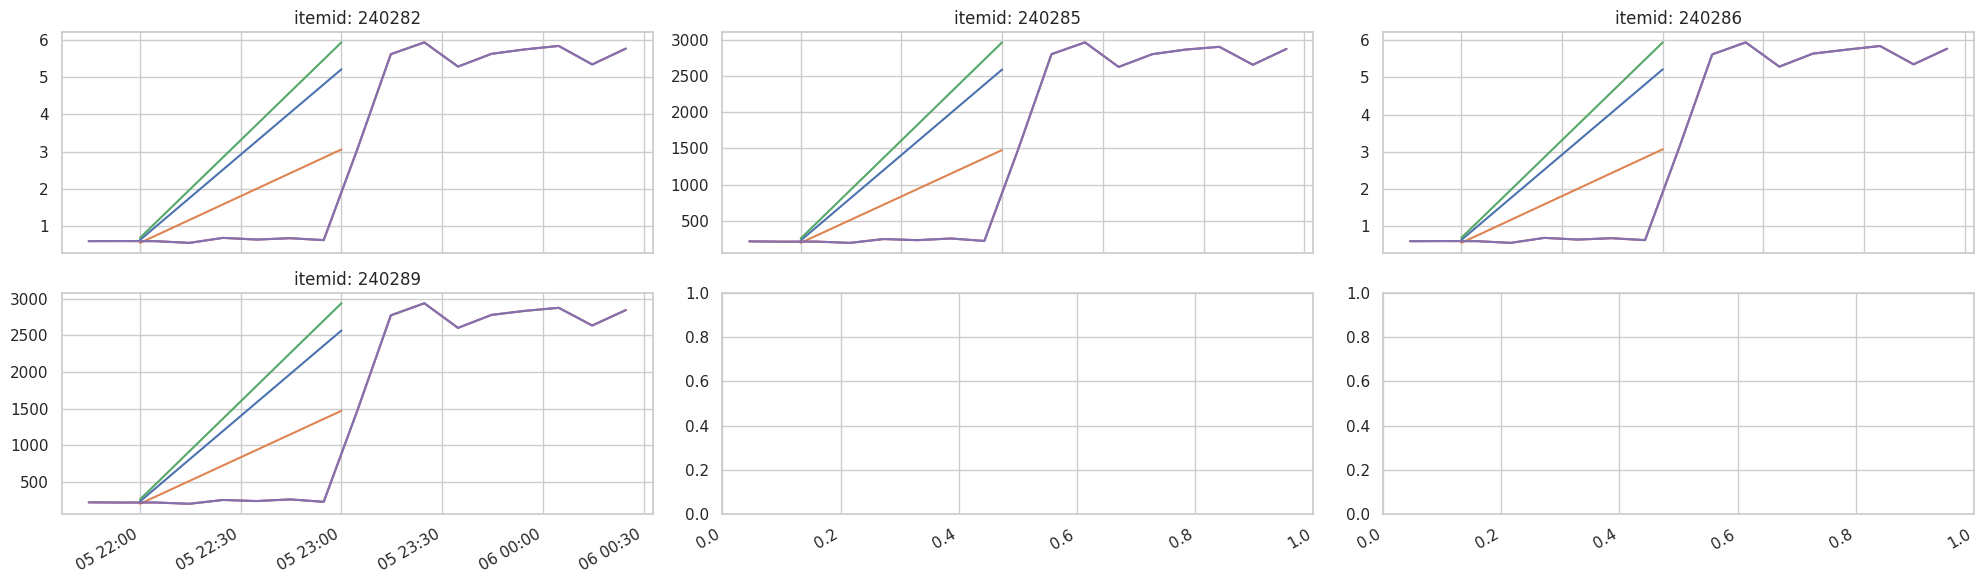

KeyError: 2

In [6]:
#plot_charts(classes[0])
plot_charts(classes[1])
plot_charts(classes[2])
plot_charts(classes[3])
plot_charts(classes[4])
plot_charts(classes[5])
plot_charts(classes[6])
plot_charts(classes[7])